# NBA Player Value Analysis

This project analyzes the 2022-23 NBA season to identify which players 
provide the best value relative to their salary. Using a dataset of NBA 
player stats and salaries, I created a Value Score by dividing each 
player's Player Efficiency Rating (PER) by their adjusted salary. 
Players were filtered to 65+ games played to ensure a fair comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression



In [2]:
import pandas as pd 
df = pd.read_csv('nba_stats_salaries.csv')
print(df.shape)
print(df.head())


(896, 35)
   Rk                   Player  Age Team Pos     G    GS    MP    FG   FGA  \
0   1              Joel Embiid   28  PHI   C  66.0  66.0  34.6  11.0  20.1   
1   2              Luka Dončić   23  DAL  PG  66.0  66.0  36.2  10.9  22.0   
2   3           Damian Lillard   32  POR  PG  58.0  58.0  36.3   9.6  20.7   
3   4  Shai Gilgeous-Alexander   24  OKC  PG  68.0  68.0  35.5  10.4  20.3   
4   5    Giannis Antetokounmpo   28  MIL  PF  63.0  63.0  32.1  11.2  20.3   

   ...  STL  BLK  TOV   PF   PTS                   Awards  Player-additional  \
0  ...  1.0  1.7  3.4  3.1  33.1  MVP-1DPOY-9CPOY-5ASNBA1          embiijo01   
1  ...  1.4  0.5  3.6  2.5  32.4        MVP-8CPOY-8ASNBA1          doncilu01   
2  ...  0.9  0.3  3.3  1.9  32.2            CPOY-10ASNBA3          lillada01   
3  ...  1.6  1.0  2.8  2.8  31.4        MVP-5CPOY-7ASNBA1          gilgesh01   
4  ...  0.8  0.8  3.9  3.1  31.1        MVP-3DPOY-6ASNBA1          antetgi01   

   Season Type   PER  Adjusted Salary  


## Data Cleaning

First, I removed duplicate player entries keeping only each player's 
first appearance. I also filtered the dataset to only include Regular 
Season stats, removing the 2 Playoff entries.

In [3]:
df = df.drop_duplicates(subset='Player' , keep = 'first')
print(df.shape)

(541, 35)


In [4]:
print(df['Season Type'].value_counts())


Season Type
Regular    539
Playoff      2
Name: count, dtype: int64


In [5]:
df = df[df['Season Type'] == 'Regular']
print(df.shape)
print(df.isnull().sum())

(539, 35)
Rk                   0
Player               0
Age                  0
Team                 0
Pos                  0
G                    0
GS                   0
MP                   0
FG                   0
FGA                  0
FG%                  0
3P                   0
3PA                  0
3P%                  0
2P                   0
2PA                  0
2P%                  0
eFG%                 0
FT                   0
FTA                  0
FT%                  0
ORB                  0
DRB                  0
TRB                  0
AST                  0
STL                  0
BLK                  0
TOV                  0
PF                   0
PTS                  0
Awards               0
Player-additional    0
Season Type          0
PER                  0
Adjusted Salary      0
dtype: int64


## Feature Engineering: Value Score

To measure each player's value, I created a new column called 
'Value Score' by dividing their Player Efficiency Rating (PER) 
by their Adjusted Salary, multiplied by 1,000,000 to make the 
numbers easier to read. A higher Value Score means a player is 
producing more efficiency per dollar spent.

In [6]:
df['Value'] = (df['PER'] / df['Adjusted Salary']) * 1000000
print(df[['Player', 'PER', 'Adjusted Salary', 'Value']].head(10))                                   

                     Player   PER  Adjusted Salary     Value
0               Joel Embiid  31.4      35605377.25  0.881889
1               Luka Dončić  28.7      39290951.43  0.730448
2            Damian Lillard  26.7      45006144.50  0.593252
3   Shai Gilgeous-Alexander  27.2      32742459.52  0.830726
4     Giannis Antetokounmpo  29.0      45006144.50  0.644356
5              Jayson Tatum  23.7      32147246.07  0.737233
6             Stephen Curry  24.1      50913606.01  0.473351
7              Kevin Durant  25.9      46729763.91  0.554251
10             LeBron James  23.9      47105915.47  0.507367
11         Donovan Mitchell  22.9      32742459.52  0.699398


## Filtering: 65+ Games Played

To ensure a fair comparison, I filtered players to only those 
who played 65 or more games. This is the NBA's official threshold 
for postseason award eligibility, so it removes players who missed 
significant time due to injury or rest.

In [7]:
df = df.sort_values(by='Value', ascending=False)
df = df[df['G']>= 65]
print(df[['Player', 'PER', 'Adjusted Salary', 'Value']].head(10))

             Player   PER  Adjusted Salary      Value
508       Paul Reed  19.2       1888072.33  10.169102
371    Jock Landale  16.4       1656008.24   9.903332
292   Nick Richards  18.3       1888072.33   9.692425
262  Daniel Gafford  19.7       2044890.85   9.633766
169        Naz Reid  18.5       2044890.85   9.046938
467   Chimezie Metu  17.3       2023897.33   8.547864
137       Tre Jones  16.0       1888072.33   8.474252
143       KJ Martin  15.4       1888072.33   8.156467
369    Drew Eubanks  16.2       2084602.82   7.771265
253  Walker Kessler  21.5       2855906.12   7.528259


In [13]:
df = df.sort_values(by='Value', ascending=False)
top10 = df[['Player', 'PER', 'Adjusted Salary', 'Value']].head(10)
print(top10)

             Player   PER  Adjusted Salary      Value
508       Paul Reed  19.2       1888072.33  10.169102
371    Jock Landale  16.4       1656008.24   9.903332
292   Nick Richards  18.3       1888072.33   9.692425
262  Daniel Gafford  19.7       2044890.85   9.633766
169        Naz Reid  18.5       2044890.85   9.046938
467   Chimezie Metu  17.3       2023897.33   8.547864
137       Tre Jones  16.0       1888072.33   8.474252
143       KJ Martin  15.4       1888072.33   8.156467
369    Drew Eubanks  16.2       2084602.82   7.771265
253  Walker Kessler  21.5       2855906.12   7.528259


## Results: Best and Worst Value Players

The following charts visualize the top 10 best value players 
and the top 10 most overpaid players in the 2022-23 NBA season 
based on their Value Score. Rookie and minimum contract players 
naturally score highest since they produce solid efficiency at 
a fraction of the cost of max contract players.

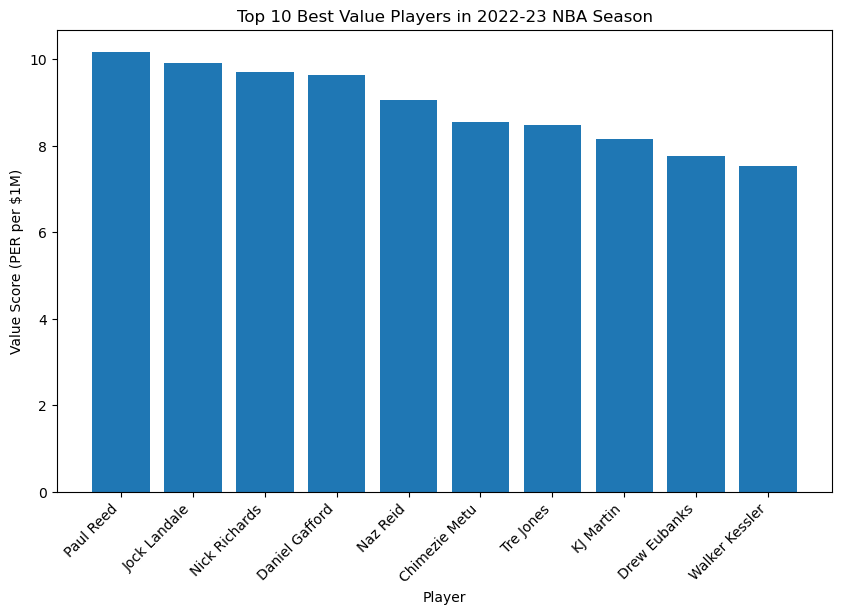

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(top10['Player'], top10['Value'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Best Value Players in 2022-23 NBA Season')
plt.xlabel('Player')
plt.ylabel('Value Score (PER per $1M)')
plt.show()

In [20]:
df = df.sort_values(by='Value', ascending=True)
bottom10 = df[['Player', 'PER', 'Adjusted Salary', 'Value']].head(10)
print(bottom10)

                Player   PER  Adjusted Salary     Value
96   Russell Westbrook  16.1      49865217.11  0.322870
39       Klay Thompson  14.7      43001786.46  0.341846
113      Tobias Harris  14.8      39859241.16  0.371307
47         CJ McCollum  15.6      35305173.48  0.441862
278     Draymond Green  12.2      27333055.16  0.446346
131        Rudy Gobert  18.9      40430511.35  0.467469
24         Zach LaVine  19.0      39290951.43  0.483572
75    D'Angelo Russell  16.3      33233907.54  0.490463
406      Nicolas Batum  11.0      20865695.60  0.527181
66        Jrue Holiday  19.2      36349698.58  0.528202


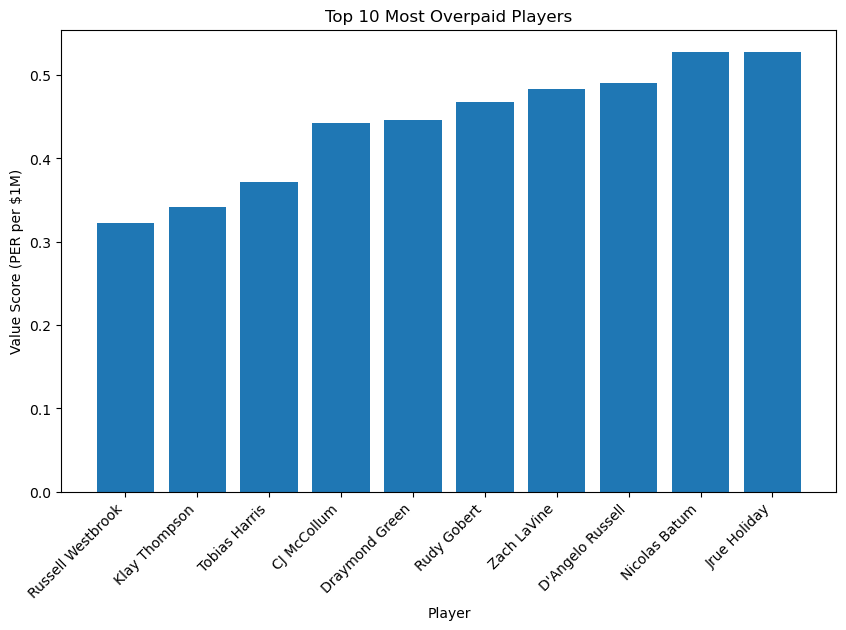

In [25]:
plt.figure(figsize=(10,6))
plt.bar(bottom10['Player'], bottom10['Value'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Overpaid Players')
plt.xlabel('Player')
plt.ylabel('Value Score (PER per $1M)')
plt.show()

To summarize this data, when you take a player's "PER" ( player efficiency rating) and divide it by their contracts, you can put a value on how valuable they are on the team. The first graph shows you the players who are performing well based on their salary and lists the top 10 in value based on salary. The second graph does the opposite and shows you the player not performing up to the standard of their salary. I also added the filter so that it only showed the players who played 65+ games, as that is the required number of games played to receive postseason awards.